Instructor supplement: Chickpea hydration analysis
==================================================



S. Singleton ssinglet@coe.edu

Using `scipy.curve_fit` and the Peleg equation to fit chickpea hydration data.

Data are taken from &ldquo;Can We Make Stew With These Beans Handbook&rdquo; (2016) POGIL-PCL experiment. The handbook has tables of representative student data for each Thinking About the Data (TATD) section:

-   TATD 1: chickpea-hbdata1.csv; 0M, 2M, 3M NaCl times/masses in long format
-   TATD 2: chickpea-hbdata2.csv; 1M, 3M.

It seems there are conflicting labels in the sample data.  Results are labeled &ldquo;1M NaCl&rdquo; and $k_{1},\ k_{2}$ reported. However, the column label for the data below these results are labeled &ldquo;Water uptake pure water normalized&rdquo;. The values for $k_{1}$ and $k_{2}$ seem to be closer to the 0M (pure water) data in TATD1, so the data column label is probably correct.



## Python Environment



In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
np.set_printoptions(legacy='1.25') # turns off 'np.float64' when printing
from scipy.optimize import curve_fit

## Import Part 1 data



Importing data could be done using pandas, but np.genfromtxt() avoids adding another dependency.



In [2]:
# Load data file into standard jupyter notebook
fn = "chickpea-hbdata1.csv"
data = np.genfromtxt(fn, skip_header=2, delimiter=",")

Uncomment and run the next two cells if using Colab.  Otherwise skip these two cells.



In [3]:
## If using google Colab, will need to upload data file
#from google.colab import files
#import io
#fn = "chickpea-hbdata1.csv"
#ul = files.upload()

In [4]:
# run this cell only if using colab
#data = np.genfromtxt(io.BytesIO(ul[fn]), skip_header=2, delimiter=",")

## Parse and plot arrays



In [5]:
# subset the data by molarity (M)
# and keep the last two columns (time, mass)
M0 = data[data[:,0] == 0][:,1:]
M2 = data[data[:,0] == 2][:,1:]
M3 = data[data[:,0] == 3][:,1:]
runs = [M0, M2, M3]
concs = ["0 M", "2 M", "3 M"]

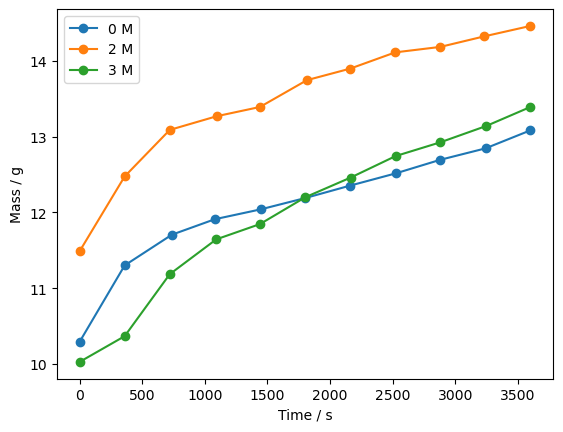

In [6]:
for run, conc in zip(runs, concs):
    plt.plot(*run.T, 'o-', label=conc)
plt.xlabel("Time / s")
plt.ylabel("Mass / g")
plt.legend()

Normalize using mass difference:

$$ \text{normalized mass} = \frac{\text{mass}_i - \text{mass}_0} {\text{mass}_i}$$



In [7]:
# normalize the data by the mass at time t=0
for run in runs:
    mass_0 = run[0,1]
    run[0,1] = run[0,1] - mass_0
    run[1:,1] = (run[1:,1] - mass_0) / run[1:,1]

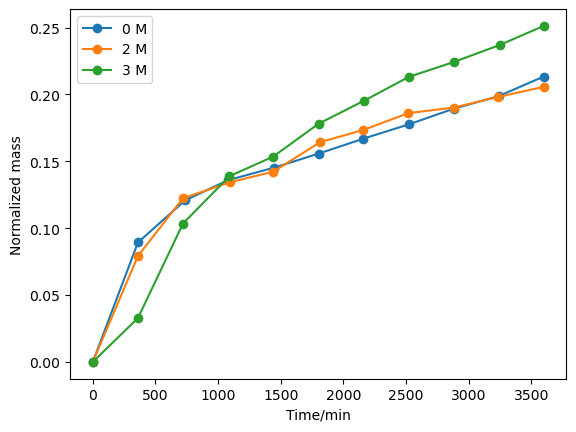

In [8]:
for run, conc in zip(runs, concs):
    plt.plot(*run.T, 'o-', label=conc)
plt.xlabel("Time/min")
plt.ylabel("Normalized mass")
plt.legend()

## Fit 0 M (pure water) hydration to Peleg equation



Peleg model function for curve\_fit.



In [9]:
def peleg(t, k1, k2):
    return t/(k1 + k2*t)

In [10]:
time, mass_norm = M0.T
time = time/60  # minutes
popt, pcov = curve_fit(peleg, time, mass_norm)

# residuals
resids = mass_norm - peleg(time, *popt)
ssr = np.sum(resids**2)
perr = np.sqrt(np.diag(pcov))
print(popt,ssr)

[55.14101669  4.16015576] 0.0008694758909539406


Plot data to examine quality of fit.



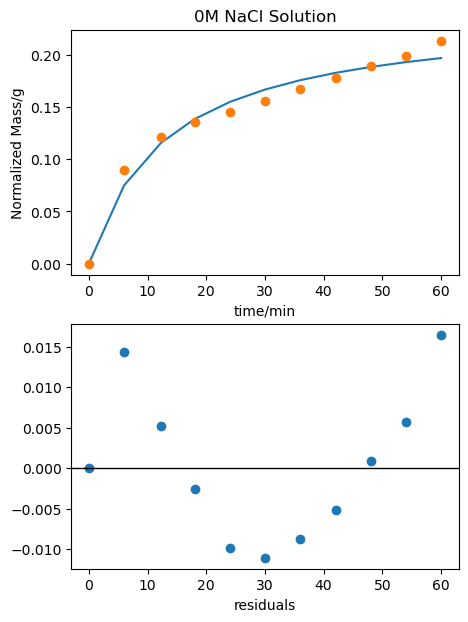

In [11]:
k1, k2 = popt

fig = plt.figure(figsize=(5,7))
plt.subplot(211)
plt.plot(time, peleg(time, k1, k2))
plt.plot(time, mass_norm, 'o')
plt.xlabel("time/min"); plt.ylabel("Normalized Mass/g")
plt.title("0M NaCl Solution")
plt.subplot(212)
plt.plot(time, resids, 'o')
plt.xlabel("residuals")
plt.axhline(0, lw=1, color='k')

Looks like there is &ldquo;structure&rdquo; to the residuals in the region where both mechanisms contribute substantially to the water uptake.  Recall, the Peleg equation is empirical.

curve\_fit optimizes the fit without passing initial guesses for $k_{1}$, $k_{2}$. However, because students are asked to estimate where $k_1$ and $k_2$ dominate in the limits of short and long times (see questions 18&#x2013;20), it may be instructive to have them supply the initial guesses.  If so, add the &ldquo;p0&rdquo; argument to curve\_fit (initial guess parameters).



In [12]:
guess = [50, 2] # initial guesses for k1, k2
popt, pcov = curve_fit(peleg, time, mass_norm, guess)
popt

array([55.14119368,  4.16015057])

## Fitting Handbook Data for 1M and 2M



In [13]:
results = []
concs = ["0 M", "1 M", "2 M"]
for run, conc in zip(runs, concs):
    time, mass = run.T
    time = time/60
    popt, pcov = curve_fit(peleg, time, mass)
    ssr = np.sum((mass_norm - peleg(time, *popt))**2)
    results.append([conc, *popt, ssr])
results

[['0 M', 55.14101669182214, 4.16015575804435, 0.0008694758909539406],
 ['1 M', 57.537505141168225, 4.060291139176462, 0.0009207373643422545],
 ['2 M', 97.2221842464588, 2.390428181652166, 0.008942522232463692]]

## Polynomial fit



There are myriad polynomial fitting functions available in python. This example sticks with using curve\_fit to give practice with its use.



In [14]:
def poly2(t, a, b, c):
    "Second order polynomial fit function for curve_fit"
    return a*t**2 + b*t + c

popt, pcov = curve_fit(poly2, time, mass_norm)
perr = np.sqrt(np.diag(pcov))
perr

array([1.81080125e-05, 1.12874322e-03, 1.45736121e-02])

err = 1.8e-05  1.1e-03  1.5e-02


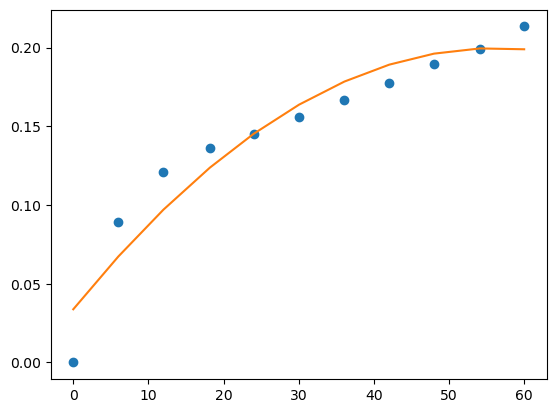

In [15]:
plt.plot(time, mass_norm, 'o')
plt.plot(time, poly2(time, *popt))

print(f"err = {perr[0]:.1e}  {perr[1]:.1e}  {perr[2]:.1e}")

Using np.polyfit():



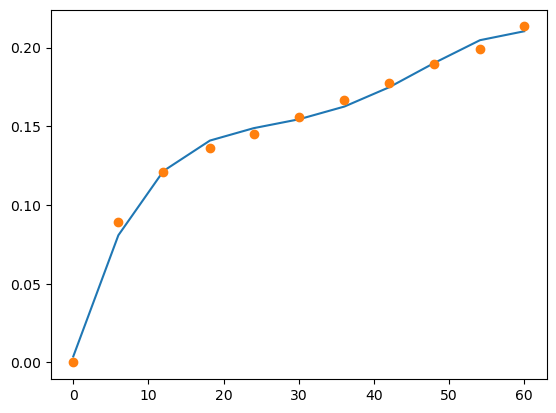

In [16]:
degree = 4
fit = np.polyfit(time, mass_norm, degree)
plt.plot(time, np.polyval(fit, time))
plt.plot(time, mass_norm, 'o')

## Handbook data from TATD Part 2



Later in the handbook, there are tables with data different than the initial table presented. This section repeats the analysis with these data.



In [17]:
fn = "chickpea-hbdata2.csv"
data = np.genfromtxt(fn, skip_header=2, delimiter=",")

Uncomment and run the next two cells if using Colab.  Otherwise skip these two cells.



In [18]:
# run this cell only if using colab
#from google.colab import files
#import io
#fn = "chickpea-hbdata2.csv"
#ul = files.upload()

In [19]:
# run this cell only if using colab
#data = np.genfromtxt(io.BytesIO(ul[fn]), skip_header=2, delimiter=",")

In [20]:
# M1a = 1M from second data set
M1a = data[data[:,0] == 1][:,1:]
M3 = data[data[:,0] == 3][:,1:]
runs = [M1a, M3]
concs = ["1 Ma", "3 M"]

# normalize the data by the mass at time t=0
for run in runs:
    mass_0 = run[0,1]
    run[0,1] = run[0,1] - mass_0
    run[1:,1] = (run[1:,1] - mass_0) / run[1:,1]

In [21]:
time, mass_norm = M1a.T
popt, pcov = curve_fit(peleg, time, mass_norm)

for run, conc in zip(runs, concs):
    time, mass = run.T
    popt, pcov = curve_fit(peleg, time, mass)
    ssr = np.sum((mass_norm - peleg(time, *popt))**2)
    results.append([conc, *popt, ssr])
results

[['0 M', 55.14101669182214, 4.16015575804435, 0.0008694758909539406],
 ['1 M', 57.537505141168225, 4.060291139176462, 0.0009207373643422545],
 ['2 M', 97.2221842464588, 2.390428181652166, 0.008942522232463692],
 ['1 Ma', 52.115386897254936, 3.0737605764373654, 0.0011981759819281609],
 ['3 M', 66.10808696341903, 3.10630617050075, 0.0045889929713654075]]